# Battery Thermal Model – B0005

Loading the NASA battery dataset, building a basic thermal model and fitting it to real discharge data.
The idea is to track how internal resistance (R) and heat transfer (hA) change over the battery's lifetime.

Dataset: B0005.mat

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.optimize import curve_fit

In [2]:
# load the .mat file - scipy reads it as a nested dict
data_dir = "../data/raw"
file_path = os.path.join(data_dir, "B0005.mat")

mat_data = sio.loadmat(file_path)
print("keys:", mat_data.keys())

# the actual data is buried inside 'B0005' as a MATLAB struct
# [0,0] is just how scipy unpacks it
battery = mat_data['B0005'][0, 0]
print("struct fields:", battery.dtype.names)

all_cycles = battery['cycle'][0]
print("number of cycles:", len(all_cycles))
print("fields in one cycle:", all_cycles[0].dtype.names)


keys: dict_keys(['__header__', '__version__', '__globals__', 'B0005'])
struct fields: ('cycle',)
number of cycles: 616
fields in one cycle: ('type', 'ambient_temperature', 'time', 'data')


In [3]:
def get_cycle_df(cycle):
    """Unpack one cycle struct into a DataFrame."""
    d = cycle['data'][0, 0]  # shorthand for the inner struct

    return pd.DataFrame({
        'time_s':    d['Time'][0],
        'current_A': d['Current_measured'][0],
        'voltage_V': d['Voltage_measured'][0],
        'temp_C':    d['Temperature_measured'][0],
    })


# grab the first discharge cycle to check things look right
for cyc in all_cycles:
    if cyc['type'][0] == 'discharge':
        first_df = get_cycle_df(cyc)
        break

print(first_df.head())


   time_s  current_A  voltage_V     temp_C
0   0.000  -0.004902   4.191492  24.330034
1  16.781  -0.001478   4.190749  24.325993
2  35.703  -2.012528   3.974871  24.389085
3  53.781  -2.013979   3.951717  24.544752
4  71.922  -2.011144   3.934352  24.731385


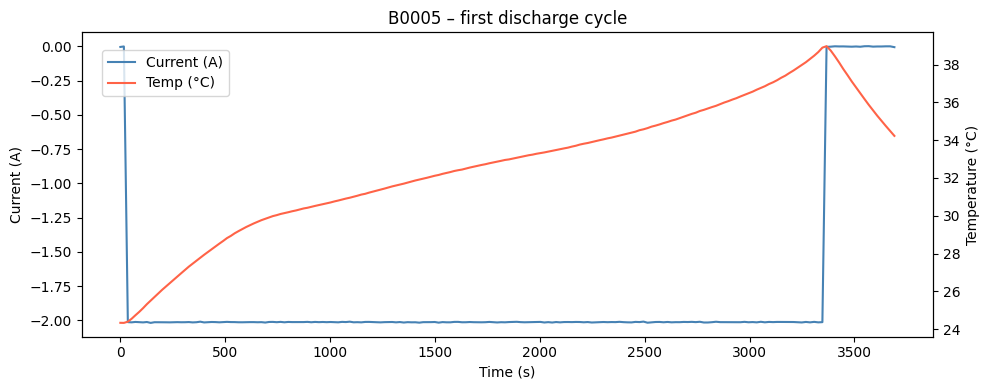

In [4]:
# quick look at raw data before doing any modelling
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(first_df['time_s'], first_df['current_A'], color='steelblue', label='Current (A)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Current (A)')

ax2 = ax1.twinx()
ax2.plot(first_df['time_s'], first_df['temp_C'], color='tomato', label='Temp (°C)')
ax2.set_ylabel('Temperature (°C)')

plt.title('B0005 – first discharge cycle')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()


## Thermal Model

Simple lumped-capacitance heat balance:

$$m C_p \frac{dT}{dt} = I^2 R_{int} - hA(T - T_{amb})$$

- $m$ = 0.045 kg, $C_p$ = 900 J/kgK (fixed, from 18650 cell specs)
- $R_{int}$ and $hA$ are what we're fitting


In [5]:
# physical constants – same for every cycle
cell_mass = 0.045   # kg (standard 18650)
Cp = 900            # J/(kg·K) – specific heat, roughly right for Li-ion


def simulate_temp(current, dt, T0, T_amb, R, hA):
    """
    Forward Euler simulation of battery temperature.

    Heat in  = I^2 * R  (joule heating)
    Heat out = hA * (T - T_amb)  (convection to surroundings)
    dT each step = (Q_in - Q_out) * dt / (m * Cp)
    """
    T = np.zeros(len(current))
    T[0] = T0

    for i in range(1, len(current)):
        Q_in  = current[i]**2 * R
        Q_out = hA * (T[i-1] - T_amb)
        T[i]  = T[i-1] + (Q_in - Q_out) * dt / (cell_mass * Cp)

    return T


In [6]:
# get ambient temp from the first discharge cycle
for cyc in all_cycles:
    if cyc['type'][0] == 'discharge':
        T_amb_first = cyc['ambient_temperature'][0][0]
        break

dt = np.mean(np.diff(first_df['time_s']))  # average timestep
I_data = first_df['current_A'].values
T_meas = first_df['temp_C'].values
T0 = T_meas[0]

# curve_fit needs f(x, *params) form, x isn't used here but it's required
def wrapper_first(x, R, hA):
    return simulate_temp(I_data, dt, T0, T_amb_first, R, hA)

p0 = [0.01, 0.1]  # starting guesses for R and hA

popt, _ = curve_fit(wrapper_first, first_df['time_s'], T_meas, p0=p0)
R_fit, hA_fit = popt

print(f"R = {R_fit:.6f} Ohm")
print(f"hA = {hA_fit:.6f} W/K")


R = 0.074190 Ohm
hA = 0.018136 W/K


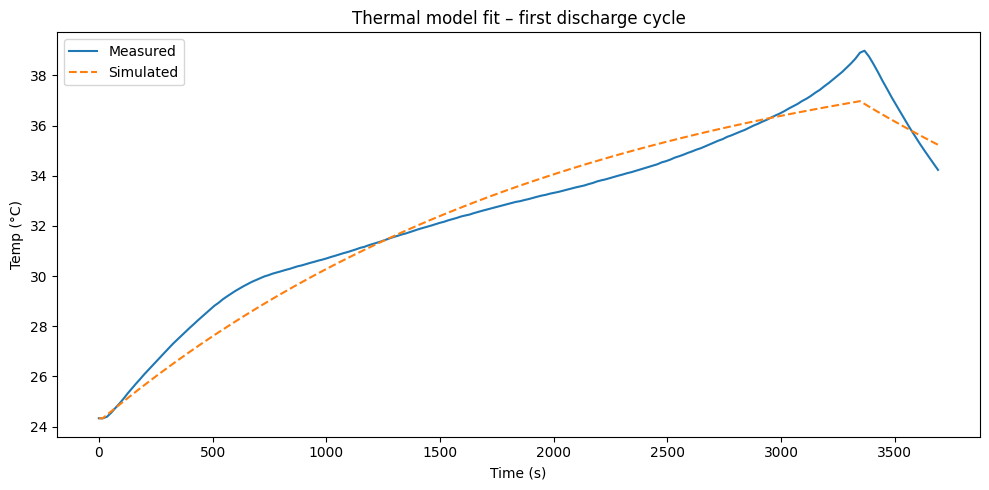

In [7]:
T_sim = simulate_temp(I_data, dt, T0, T_amb_first, R_fit, hA_fit)

plt.figure(figsize=(10, 5))
plt.plot(first_df['time_s'], T_meas, label='Measured')
plt.plot(first_df['time_s'], T_sim, '--', label='Simulated')
plt.xlabel('Time (s)')
plt.ylabel('Temp (°C)')
plt.title('Thermal model fit – first discharge cycle')
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# fit R and hA for every discharge cycle
# this takes a while to run (~few minutes)
results = []

for idx, cyc in enumerate(all_cycles):

    if cyc['type'][0] != 'discharge':
        continue

    df_c = get_cycle_df(cyc)
    T_amb_c = cyc['ambient_temperature'][0][0]

    if len(df_c) < 10:  # too short to fit properly
        continue

    dt_c = np.mean(np.diff(df_c['time_s']))
    I_c  = df_c['current_A'].values
    T_c  = df_c['temp_C'].values
    T0_c = T_c[0]

    def make_wrapper(I, dt, T0, T_amb):
        # using a closure so each iteration captures its own variables
        def fn(x, R, hA):
            return simulate_temp(I, dt, T0, T_amb, R, hA)
        return fn

    try:
        popt, _ = curve_fit(make_wrapper(I_c, dt_c, T0_c, T_amb_c),
                            df_c['time_s'], T_c,
                            p0=[0.01, 0.1], maxfev=5000)
        results.append({
            'cycle': idx + 1,
            'R_fit': popt[0],
            'hA_fit': popt[1]
        })
    except RuntimeError:
        continue  # didn't converge, skip

results_df = pd.DataFrame(results)
print(f"fitted {len(results_df)} cycles")
print(results_df.head())


fitted 168 cycles
   cycle     R_fit    hA_fit
0      2  0.074190  0.018136
1      4  0.072998  0.017482
2      6  0.072514  0.017554
3      8  0.070731  0.016911
4     10  0.069654  0.016631


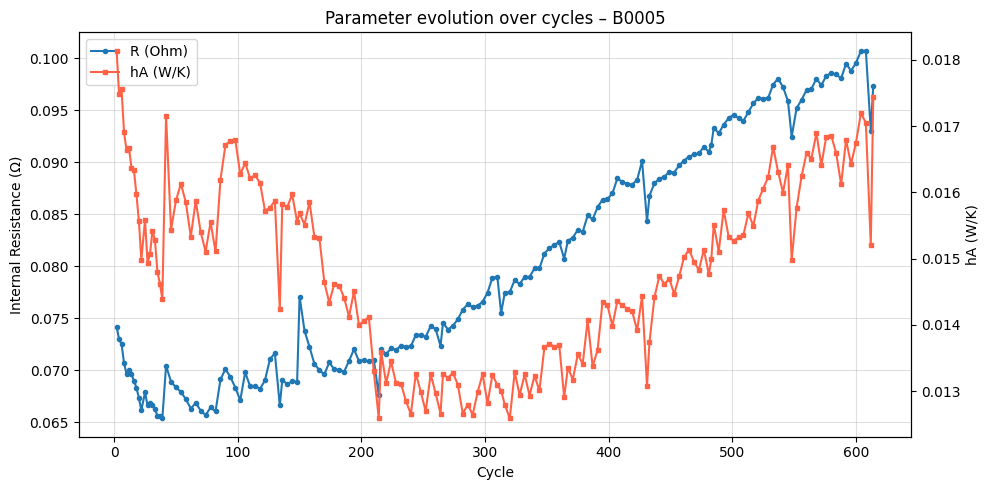

In [9]:
# plot how R and hA change as the battery ages
# R should slowly go up – that's a sign of degradation
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(results_df['cycle'], results_df['R_fit'], '-o', markersize=3, label='R (Ohm)')
ax1.set_xlabel('Cycle')
ax1.set_ylabel('Internal Resistance (Ω)')
ax1.grid(True, alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(results_df['cycle'], results_df['hA_fit'], '-s', markersize=3,
         color='tomato', label='hA (W/K)')
ax2.set_ylabel('hA (W/K)')

# merge the two legends
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left')

plt.title('Parameter evolution over cycles – B0005')
plt.tight_layout()
plt.show()


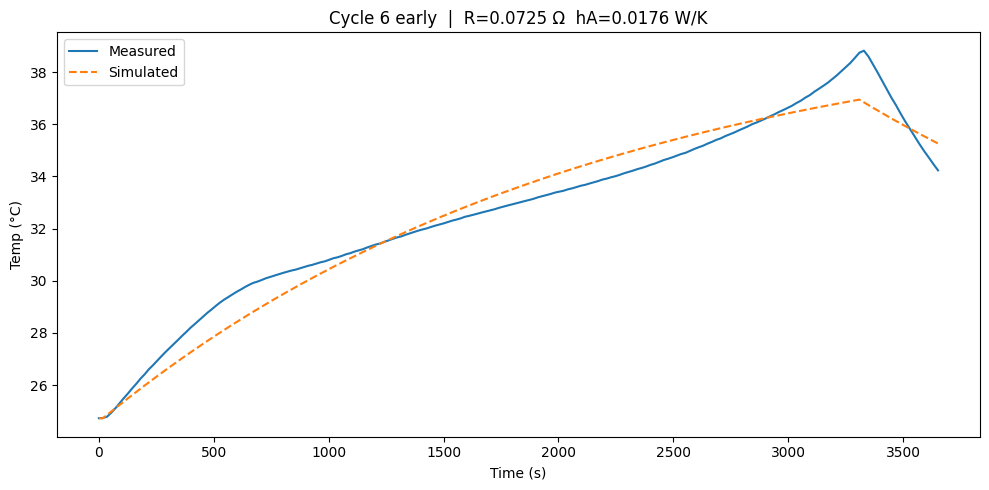

cycle 150 is not a discharge, skipping


In [10]:
def plot_cycle(cycle_idx, label=''):
    cyc = all_cycles[cycle_idx]

    if cyc['type'][0] != 'discharge':
        print(f"cycle {cycle_idx} is not a discharge, skipping")
        return

    df_c    = get_cycle_df(cyc)
    T_amb_c = cyc['ambient_temperature'][0][0]
    dt_c    = np.mean(np.diff(df_c['time_s']))
    I_c     = df_c['current_A'].values
    T_c     = df_c['temp_C'].values

    def fn(x, R, hA):
        return simulate_temp(I_c, dt_c, T_c[0], T_amb_c, R, hA)

    popt, _ = curve_fit(fn, df_c['time_s'], T_c, p0=[0.01, 0.1], maxfev=5000)
    R_c, hA_c = popt

    T_sim_c = simulate_temp(I_c, dt_c, T_c[0], T_amb_c, R_c, hA_c)

    plt.figure(figsize=(10, 5))
    plt.plot(df_c['time_s'], T_c, label='Measured')
    plt.plot(df_c['time_s'], T_sim_c, '--', label='Simulated')
    plt.xlabel('Time (s)')
    plt.ylabel('Temp (°C)')
    plt.title(f'Cycle {cycle_idx+1} {label}  |  R={R_c:.4f} Ω  hA={hA_c:.4f} W/K')
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_cycle(5,   'early')
plot_cycle(150, 'late')


In [11]:
# save so we don't have to re-run the loop every time
out_path = "../results/parameter_evolution_B0005.csv"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

results_df.to_csv(out_path, index=False)
print("saved to", out_path)
print(results_df.describe())


saved to ../results/parameter_evolution_B0005.csv
            cycle       R_fit      hA_fit
count  168.000000  168.000000  168.000000
mean   294.000000    0.079739    0.014862
std    184.947314    0.011032    0.001373
min      2.000000    0.065396    0.012590
25%    133.000000    0.070039    0.013582
50%    292.000000    0.076294    0.014982
75%    454.000000    0.089821    0.015900
max    614.000000    0.100730    0.018136


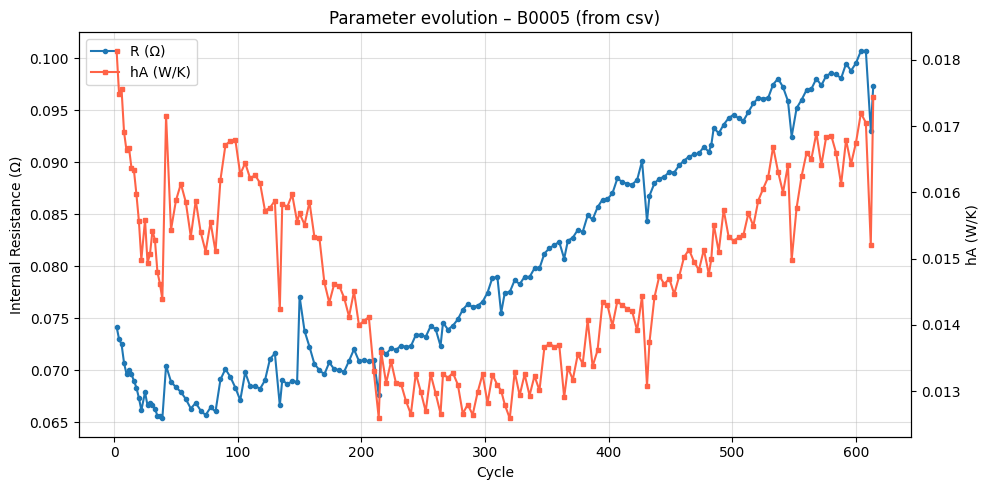

In [12]:
# reload from csv and re-plot (useful if you just want the plots without refitting)
df_params = pd.read_csv("../results/parameter_evolution_B0005.csv")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_params['cycle'], df_params['R_fit'], '-o', markersize=3, label='R (Ω)')
ax1.set_xlabel('Cycle')
ax1.set_ylabel('Internal Resistance (Ω)')
ax1.grid(True, alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(df_params['cycle'], df_params['hA_fit'], '-s', markersize=3,
         color='tomato', label='hA (W/K)')
ax2.set_ylabel('hA (W/K)')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left')

plt.title('Parameter evolution – B0005 (from csv)')
plt.tight_layout()
plt.show()
